In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
np.random.seed(42)

m = 200  # numero de ejemplos de entrenamiento
X = np.random.randn(2, m)  # shape: (n_features, m)

Epoca    0 | Costo J = 0.693147
Epoca   50 | Costo J = 0.413201
Epoca  100 | Costo J = 0.341129
Epoca  150 | Costo J = 0.307730
Epoca  200 | Costo J = 0.288361
Epoca  250 | Costo J = 0.275725
Epoca  300 | Costo J = 0.266856
Epoca  350 | Costo J = 0.260313
Epoca  400 | Costo J = 0.255306
Epoca  450 | Costo J = 0.251369

Exactitud final en entrenamiento: 89.0%
Pesos aprendidos: w = [ 1.66477373 -3.1010956 ], b = -0.2668

Costo en epoca 0: 0.693147
Costo en epoca 250: 0.275725
Costo en epoca final (499): 0.248261


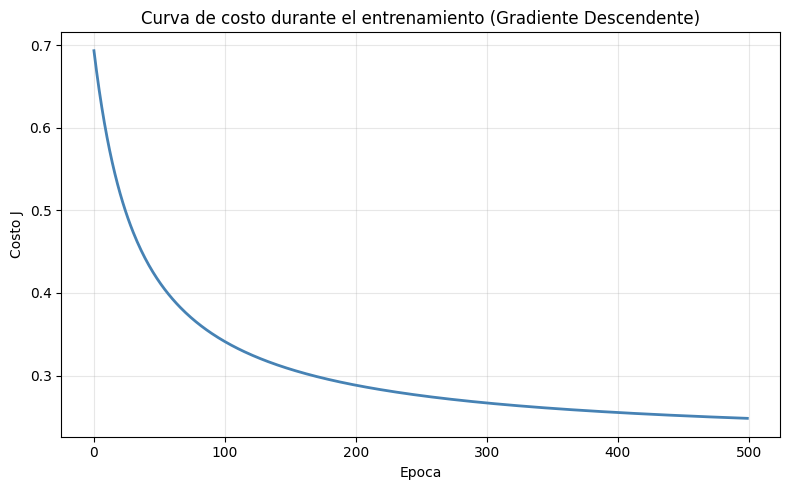

In [14]:
# Generamos etiquetas con una relacion lineal + ruido
y_true_logit = 0.8 * X[0] - 1.2 * X[1]
y = (y_true_logit + np.random.randn(m) * 0.5 > 0).astype(float)  # shape: (m,)

# Iniciamos parametros

n = X.shape[0]      # dimension de entrada: 2
w = np.zeros((n,))  # shape: (n,)
b = 0.0

alpha = 0.1   # tasa de aprendizaje
epochs = 500  # numero de iteraciones de gradiente descendente

# Funcion sigmoide
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

costos = []
epocas_guardadas = []

for epoch in range(epochs):

    # FORWARD
    # Preactivacion: z = w^T * X + b
    # X tiene shape (n, m); w tiene shape (n,)
    # np.dot(w, X) produce un vector de shape (m,)
    z = np.dot(w, X) + b          # shape: (m,)

    # Activacion sigmoide: y_hat = sigma(z)
    # y_hat es la probabilidad estimada de incumplimiento
    y_hat = sigmoid(z)             # shape: (m,)

    # Funcion de Loss
    # L = -[y * log(y_hat) + (1-y) * log(1-y_hat)]
    # Promediamos sobre todos los m ejemplos para obtener el costo J
    # Usamos clip para evitar log(0), que es indefinido
    eps = 1e-8
    J = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    # Backward - Backpropagation
    # Gradiente del costo con respecto a z:
    # dJ/dz = (1/m) * (y_hat - y)
    # Este es el resultado clave derivado en clase: el gradiente es el error
    dz = (y_hat - y)               # shape: (m,), sin dividir por m aun

    # Gradiente con respecto a w:
    # dJ/dw = (1/m) * X * dz^T
    # Como X tiene shape (n, m) y dz tiene shape (m,), np.dot produce (n,)
    dw = np.dot(X, dz) / m        # shape: (n,)

    # Gradiente con respecto a b:
    # dJ/db = (1/m) * sum(dz)
    db = np.mean(dz)               # escalar


    # Update de parametros
    # w <- w - alpha * dw
    # b <- b - alpha * db
    w = w - alpha * dw
    b = b - alpha * db

    # Guardamos todas las epocas    
    costos.append(J)
    epocas_guardadas.append(epoch)
    if epoch % 50 == 0:
        print(f"Epoca {epoch:4d} | Costo J = {J:.6f}")

z_final = np.dot(w, X) + b
y_pred = (sigmoid(z_final) >= 0.5).astype(float)
accuracy = np.mean(y_pred == y)
print(f"\nExactitud final en entrenamiento: {accuracy*100:.1f}%")
print(f"Pesos aprendidos: w = {w}, b = {b:.4f}")

# Calcular y mostrar el costo en epocas pedidas
print(f"\nCosto en epoca 0: {costos[0]:.6f}")
print(f"Costo en epoca 250: {costos[250]:.6f}")
print(f"Costo en epoca final (499): {costos[-1]:.6f}")

# Graficar la curva de costo
plt.figure(figsize=(8, 5))
plt.plot(epocas_guardadas, costos, color='steelblue', linewidth=2)
plt.xlabel('Epoca')
plt.ylabel('Costo J')
plt.title('Curva de costo durante el entrenamiento (Gradiente Descendente)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_costo.png', dpi=150)
plt.show()